# Potsdam data prep (point features)

Builds a curated local sample of real point-feature scenes from ISPRS Potsdam's `Tree` and `Car` classes -- SpaceNet has no point-object class, and at its ~0.3-0.5 m/px GSD, objects like lamp posts or manholes would be sub-pixel anyway (verified during planning). Potsdam's 6cm/px aerial ortho resolves trees and cars as compact multi-pixel blobs, a reasonable real-world stand-in for PLEM's point-feature class.

## Prerequisite (manual, one-time)

This notebook downloads the Potsdam dataset from a Kaggle mirror (the official ISPRS host requires a manual data-request form, not scriptable). You need a free Kaggle API token:

1. Create a free account at [kaggle.com](https://www.kaggle.com) if you don't have one.
2. Go to **Account -> Create New API Token** -- this downloads `kaggle.json`.
3. Save it to `~/.kaggle/kaggle.json` (on Windows: `C:\Users\<you>\.kaggle\kaggle.json`).

Without this, the download cell below will raise -- everything else in `datasets.potsdam` (palette thresholding, connected-component extraction, tiling) has already been validated against a synthetic label image and doesn't require the token.

In [1]:
import sys, os
from pathlib import Path
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt

from datasets.potsdam import (
    load_kaggle_dataset, build_potsdam_sample, label_raster_to_point_mask, PALETTE,
)

# Resolve to an absolute path so the cache lands in the repo's data/ dir
# regardless of the kernel's working directory (nbconvert runs notebooks with
# CWD set to the notebook's own folder, not the repo root).
DATA_DIR = Path("..").resolve() / "data"
N_CROPS = 15

In [2]:
# One-time download -- requires ~/.kaggle/kaggle.json (see prerequisite above).
# Safe to re-run: skips re-downloading if data/potsdam_raw already has content.
raw_dir = load_kaggle_dataset(dest=str(DATA_DIR / "potsdam_raw"))
print(f"Potsdam raw data at: {raw_dir}")

Dataset URL: https://www.kaggle.com/datasets/jahidhasan66/isprs-potsdam


Potsdam raw data at: C:\Users\danzg\PycharmProjects\PLEM\data\potsdam_raw


In [3]:
# Build the curated point-feature sample: crops the large Potsdam ortho tiles
# down to PLEM-scale chips, keeping only ones with at least one tree/car instance.
samples = build_potsdam_sample(
    n_crops=N_CROPS, seed=0,
    cache_dir=str(DATA_DIR / "potsdam"), raw_dir=str(DATA_DIR / "potsdam_raw"),
)
print(f"{len(samples)} point-feature crops cached under data/potsdam/")

15 point-feature crops cached under data/potsdam/


## Blob-size histogram

Justifies the `min_area`/`max_area` thresholds used in `label_raster_to_point_mask` (default 4-2000 px): too small to be a real tree/car is speckle noise in the label raster; too large is likely several touching instances merged into one connected component (a known limitation -- no watershed splitting).

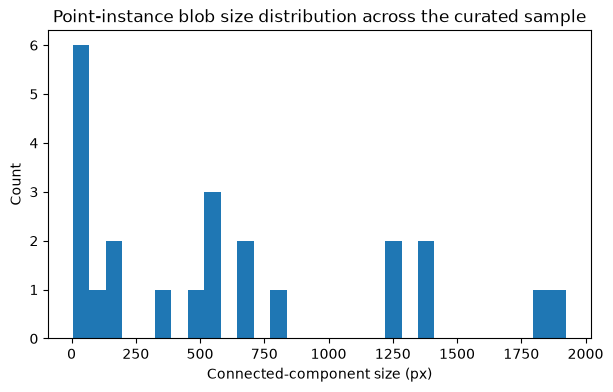

n instances: 23, median size: 538.0px


In [4]:
from scipy.ndimage import label as cc_label, sum as ndi_sum

all_sizes = []
for s in samples:
    labeled, n = cc_label(s["label"] > 0)
    if n == 0:
        continue
    ids = np.arange(1, n + 1)
    sizes = ndi_sum(np.ones_like(labeled), labeled, index=ids)
    all_sizes.extend(sizes.tolist())

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(all_sizes, bins=30)
ax.set_xlabel("Connected-component size (px)")
ax.set_ylabel("Count")
ax.set_title("Point-instance blob size distribution across the curated sample")
plt.show()
print(f"n instances: {len(all_sizes)}, median size: {np.median(all_sizes):.1f}px")

## Visual sanity check

RGB crop, colored label raster, and derived point centroids overlaid as scatter markers -- confirms the palette threshold + connected-component extraction lines up with real tree/car locations.

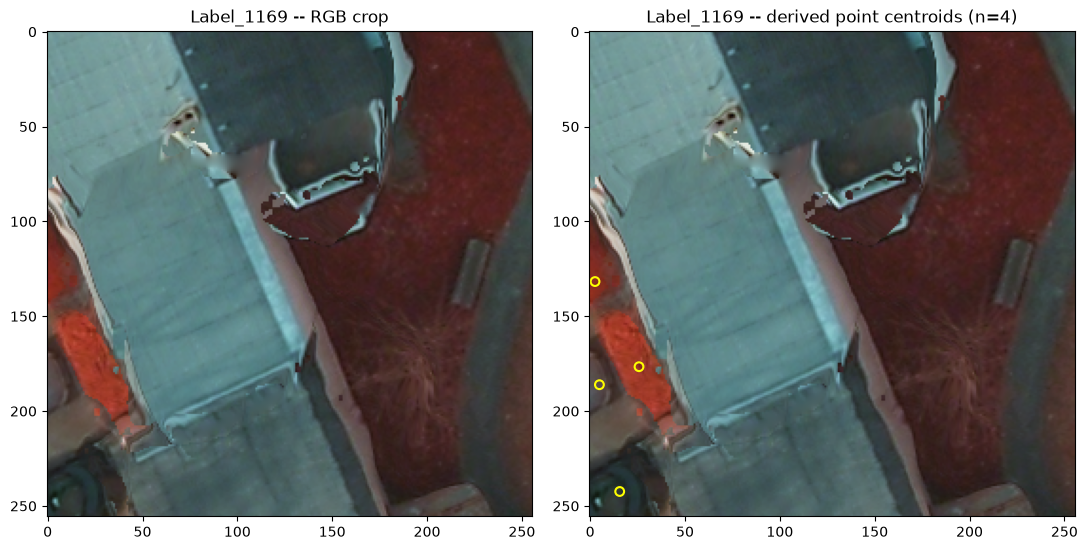

In [5]:
from scipy.ndimage import center_of_mass

# Pick the crop with the most instances for a more illustrative example
# (samples[0] is an arbitrary random draw and can be a near-empty crop).
def n_instances(sample):
    _, n = cc_label(sample["label"] > 0)
    return n

s = max(samples, key=n_instances)
image, label = s["image"], s["label"]

labeled, n = cc_label(label > 0)
centroids = center_of_mass(label > 0, labeled, range(1, n + 1)) if n > 0 else []

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
axes[0].imshow(image)
axes[0].set_title(f"{s['tile']} -- RGB crop")

axes[1].imshow(image)
if centroids:
    ys, xs = zip(*centroids)
    axes[1].scatter(xs, ys, s=40, facecolors="none", edgecolors="yellow", linewidths=1.5)
axes[1].set_title(f"{s['tile']} -- derived point centroids (n={n})")

fig.tight_layout()
plt.show()